# 01 — EDA: Give Me Some Credit

**Objetivo**: entender a cara dos dados, quantificar imbalance, identificar
outliers/sentinels, e mapear os sinais mais fortes de default.

**Findings esperados**: 150k linhas, target rate 6.68%, 20% missing em monthly_income,
sentinels 96/98 em past_due_*, past_due_90 é o preditor mais forte.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw, clean

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams["figure.dpi"] = 100

df_raw = load_raw(PROJECT_ROOT / "data" / "raw" / "cs-training.csv")
df = clean(df_raw)
print(f"Shape: {df.shape}")
print(f"Target rate: {df['target'].mean():.4%}")
df.head()

Shape: (150000, 12)
Target rate: 6.6840%


,target,revolving_utilization,age,past_due_30_59,debt_ratio,monthly_income,open_credit_lines,past_due_90,real_estate_loans,past_due_60_89,dependents,had_past_due_sentinel
0,0,0.030,57,0.000,0.283,10121.000,7,0.000,1,0.000,0.000,0
1,0,0.000,57,0.000,0.143,7750.000,9,0.000,1,0.000,0.000,0
2,0,0.037,48,0.000,0.236,6000.000,6,0.000,2,0.000,3.000,0
3,0,1.018,41,0.000,0.163,4958.000,4,0.000,0,0.000,0.000,0
4,0,1.009,49,0.000,3942.000,NaN,10,0.000,1,0.000,0.000,0


## 1. Class Imbalance

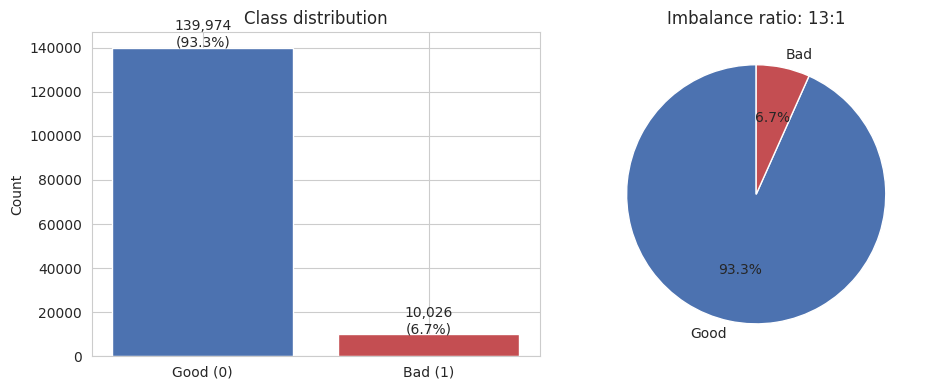

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df["target"].value_counts()
axes[0].bar(["Good (0)", "Bad (1)"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)

axes[1].pie(counts.values, labels=["Good", "Bad"], colors=["#4C72B0", "#C44E52"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title(f"Imbalance ratio: {int(counts[0]/counts[1])}:1")

fig.tight_layout()
plt.show()

## 2. Missing Values

                count    pct
monthly_income  29731 19.820
dependents       3924  2.620
past_due_30_59    269  0.180
past_due_60_89    269  0.180
past_due_90       269  0.180


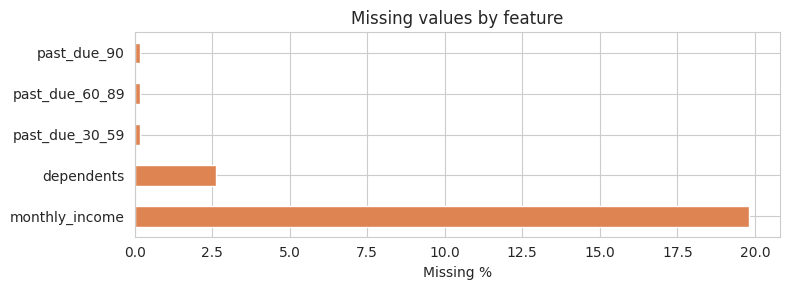

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(miss_df[miss_df["count"] > 0])

fig, ax = plt.subplots(figsize=(8, 3))
miss_df[miss_df["count"] > 0]["pct"].plot.barh(ax=ax, color="#dd8452")
ax.set_xlabel("Missing %")
ax.set_title("Missing values by feature")
fig.tight_layout()
plt.show()

## 3. Descriptive Statistics

In [4]:
good = df[df["target"] == 0]
bad  = df[df["target"] == 1]
features = [c for c in df.columns if c not in ("target", "had_past_due_sentinel")]
pd.DataFrame({
    "good_median": good[features].median(),
    "bad_median":  bad[features].median(),
    "overall_std": df[features].std(),
    "overall_max": df[features].max(),
})

,good_median,bad_median,overall_std,overall_max
revolving_utilization,0.133,0.839,249.755,50708.000
age,52.000,45.000,14.772,109.000
past_due_30_59,0.000,0.000,0.698,13.000
debt_ratio,0.363,0.428,2037.819,329664.000
monthly_income,5466.000,4500.000,14384.674,3008750.000
open_credit_lines,8.000,7.000,5.146,58.000
past_due_90,0.000,0.000,0.486,17.000
real_estate_loans,1.000,1.000,1.130,54.000
past_due_60_89,0.000,0.000,0.330,11.000
dependents,0.000,0.000,1.115,20.000


## 4. Default Rate por Coorte

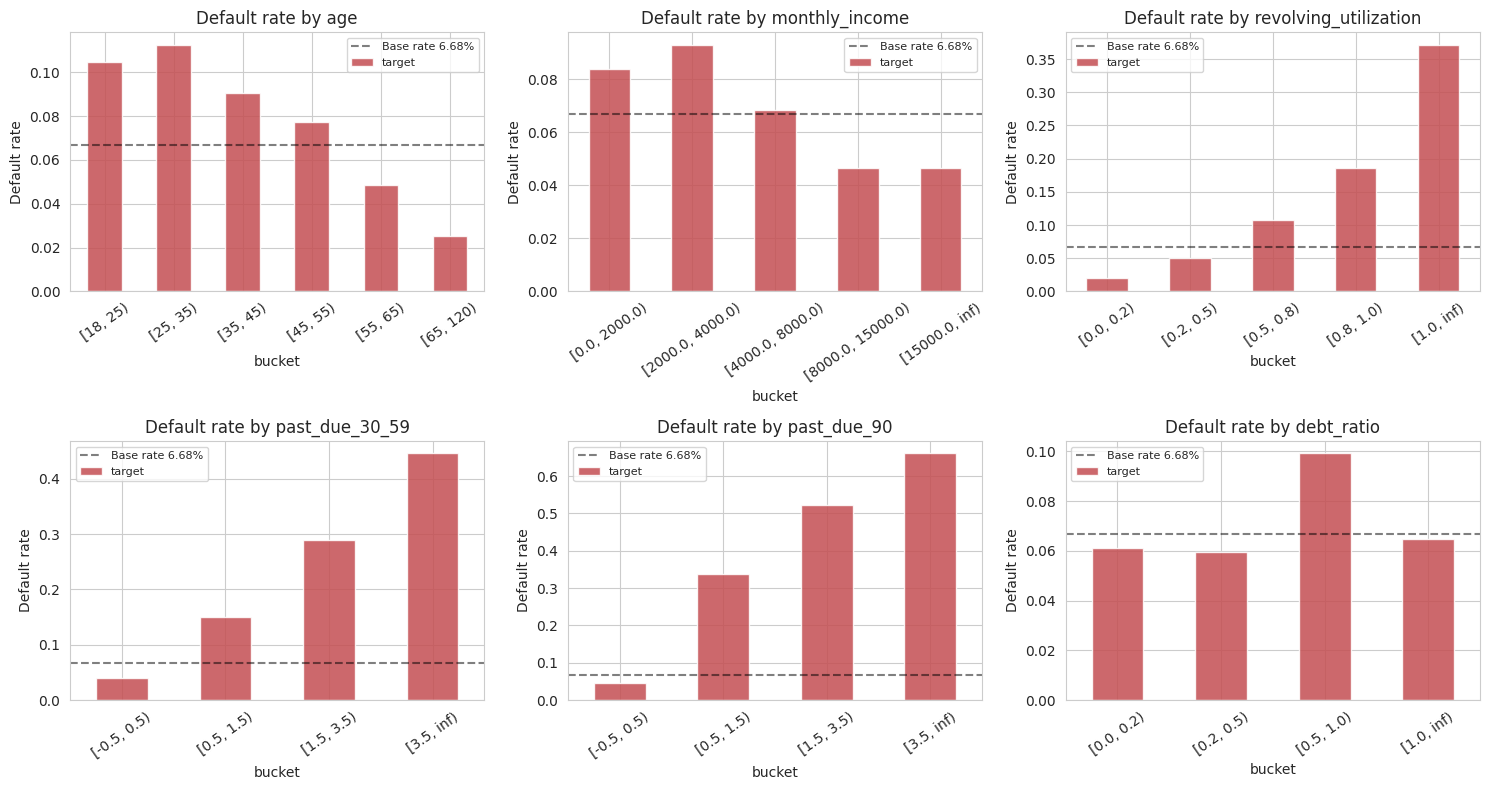

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cohorts = [
    ("age",                   [18, 25, 35, 45, 55, 65, 120]),
    ("monthly_income",        [0, 2000, 4000, 8000, 15000, float("inf")]),
    ("revolving_utilization", [0, 0.2, 0.5, 0.8, 1.0, float("inf")]),
    ("past_due_30_59",        [-0.5, 0.5, 1.5, 3.5, float("inf")]),
    ("past_due_90",           [-0.5, 0.5, 1.5, 3.5, float("inf")]),
    ("debt_ratio",            [0, 0.2, 0.5, 1.0, float("inf")]),
]

base_rate = df["target"].mean()
for ax, (feat, bins) in zip(axes, cohorts):
    tmp = df[[feat, "target"]].dropna().copy()
    tmp["bucket"] = pd.cut(tmp[feat], bins=bins, right=False)
    rates = tmp.groupby("bucket", observed=True)["target"].mean()
    rates.plot.bar(ax=ax, color="#C44E52", alpha=0.85)
    ax.set_title(f"Default rate by {feat}")
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=35)
    ax.axhline(base_rate, ls="--", color="black", alpha=0.5, label=f"Base rate {base_rate:.2%}")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Correlation Heatmap

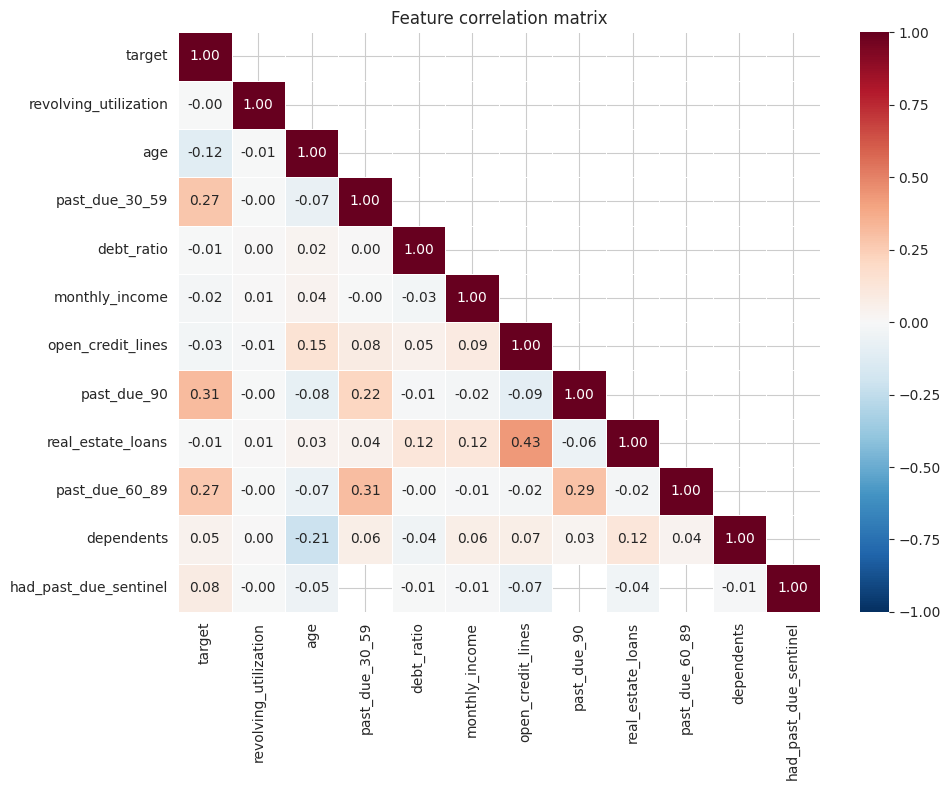


Correlation with target (sorted by magnitude):
past_due_90              0.315
past_due_30_59           0.275
past_due_60_89           0.268
age                     -0.115
had_past_due_sentinel    0.081
dependents               0.046
open_credit_lines       -0.030
monthly_income          -0.020
debt_ratio              -0.008
real_estate_loans       -0.007
revolving_utilization   -0.002
Name: target, dtype: float64


In [6]:
numeric_cols = [c for c in df.columns]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Feature correlation matrix")
fig.tight_layout()
plt.show()

print("\nCorrelation with target (sorted by magnitude):")
print(corr["target"].drop("target").sort_values(key=abs, ascending=False))

## 6. Findings e Conclusões

**Imbalance**: 93.3% good / 6.7% bad. Ratio ≈ 14:1.  
Estratégia: `class_weight='balanced'` no LogReg, `scale_pos_weight ≈ 14` no XGBoost.

**Missings**:
- `monthly_income`: 19.8% missing — mediana no baseline; XGBoost trata nativamente.
- `dependents`: 2.6% missing — mesma estratégia.

**Sentinels**: 269 linhas com 96/98 nas colunas `past_due_*`.  
Tratados como missing + flag binário `had_past_due_sentinel`.

**Sinais mais fortes**:
1. `past_due_90` — qualquer atraso >90d multiplica risco por 5-10x
2. `past_due_30_59` — sinal similar
3. `revolving_utilization` — acima de 80% dobra o risco
4. `age` — jovens têm risco maior
5. `monthly_income` — protetor, mas muito skewed